# Bike Sharing - EDA

Looking at the data before building the model. Target = cnt (bikes rented per day).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../datasets/raw/day.csv')
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


### Size and columns

In [3]:
df.shape

(731, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


### Stats

In [5]:
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


### Missing values

In [6]:
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

### Target: cnt

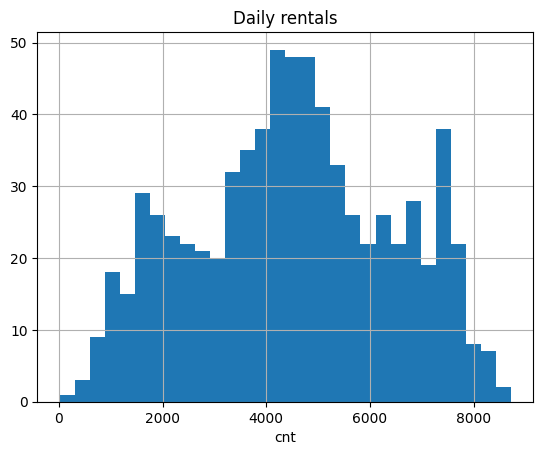

In [7]:
df['cnt'].hist(bins=30)
plt.xlabel('cnt')
plt.title('Daily rentals')
plt.show()

### Columns to drop

instant = id, dteday = date, casual + registered = cnt (so they would be cheating).

In [8]:
# check casual + registered = cnt
(df['casual'] + df['registered'] == df['cnt']).all()

np.True_

### Correlation with cnt

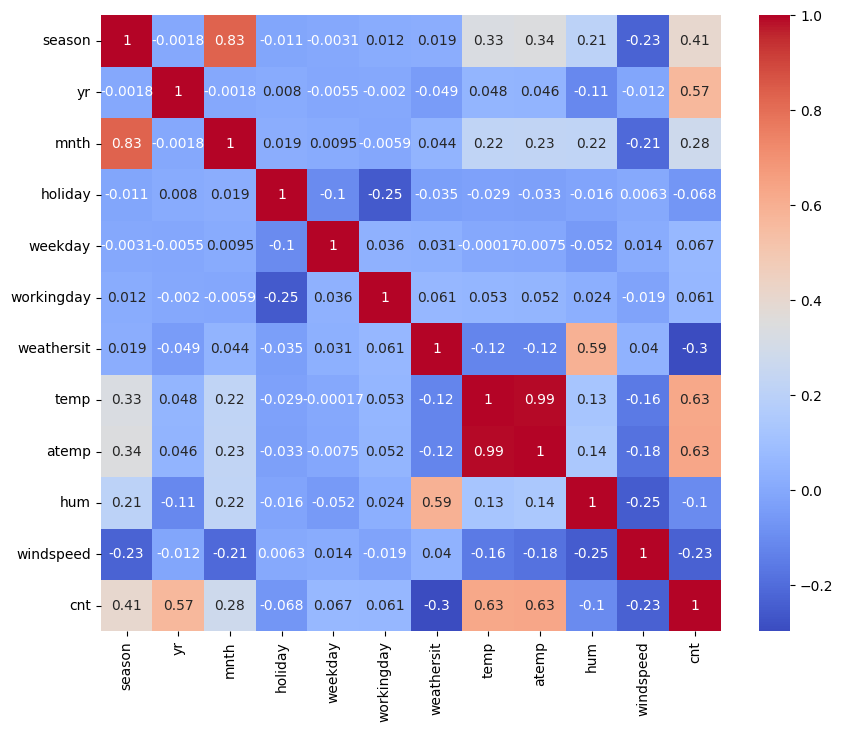

In [9]:
cols = ['season','yr','mnth','holiday','weekday','workingday','weathersit',
        'temp','atemp','hum','windspeed','cnt']
plt.figure(figsize=(10,8))
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm')
plt.show()

In [10]:
df[cols].corr()['cnt'].sort_values()

weathersit   -0.297391
windspeed    -0.234545
hum          -0.100659
holiday      -0.068348
workingday    0.061156
weekday       0.067443
mnth          0.279977
season        0.406100
yr            0.566710
temp          0.627494
atemp         0.631066
cnt           1.000000
Name: cnt, dtype: float64

### Temperature vs cnt

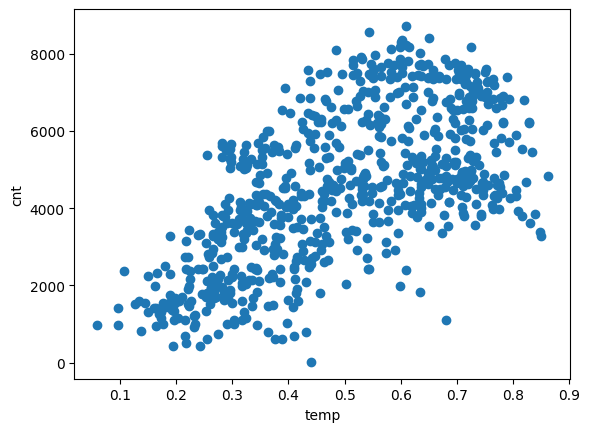

In [11]:
plt.scatter(df['temp'], df['cnt'])
plt.xlabel('temp')
plt.ylabel('cnt')
plt.show()

### cnt by season

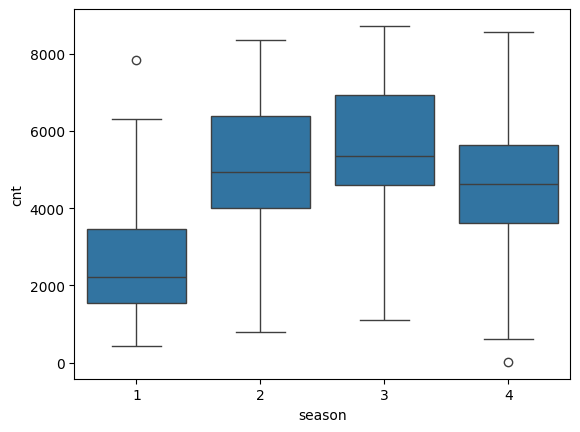

In [12]:
sns.boxplot(x='season', y='cnt', data=df)
plt.show()

### cnt by weather

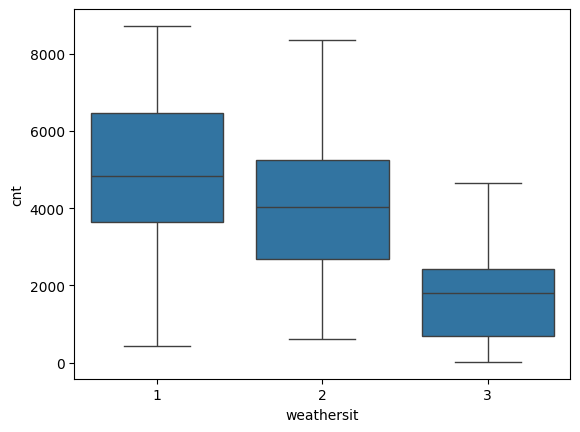

In [13]:
sns.boxplot(x='weathersit', y='cnt', data=df)
plt.show()

### Average cnt per month

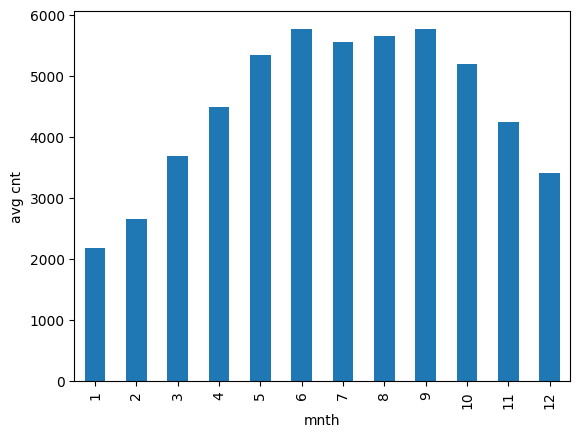

In [14]:
df.groupby('mnth')['cnt'].mean().plot(kind='bar')
plt.ylabel('avg cnt')
plt.show()

### Notes (what I see)

- The data is clean: 731 days, no missing values and no duplicates.
- casual + registered = cnt for every row, so I drop them (they would be cheating).
- cnt goes from 22 to 8714 bikes, average ~4500 per day.
- Temperature is the main driver: temp and atemp both correlate 0.63 with cnt.
- temp and atemp are almost the same (corr 0.99) -> redundant. I keep both and let Ridge/Lasso handle it.
- Year matters a lot: yr correlates 0.57. The service grew: 2011 avg ~3406 vs 2012 ~5600.
- season (0.41) and month (0.28) -> more rentals in the warm months.
- Weather is negative: weathersit -0.30 and windspeed -0.23 -> bad/windy days = fewer rentals.
- hum, weekday and workingday have little effect.

These justify the modeling: drop the leakage columns, keep temp+atemp but use regularization, and a linear model fits well (R2 ~0.88).